### Notebook running Quantum State Tomography (QST) Algorithms
Algorithms implemented:
1) Maximum Likelihood Estimation (MLE)

In [1]:
# Import Packages
import numpy as np
from ipywidgets import interact

import qutip as q
from tqdm.notebook import tqdm

from artificial_samples import cat, sqv, pssqv, spssqv, sample_homodyne
from MLE_class import MLE
from plotting import plot_dm, plot_Wigner, plot_fidelities

In [19]:
# Define target cat state parameters
N_cutoff = 50
parity = 0
alpha = np.sqrt(4)*1j
# Generate target state
state = cat(N_cutoff, parity, alpha)

In [9]:
# Define target squeezed vacuum state parameters
N_cutoff = 50
r = 1.0
# Generate target state
state = sqv(N_cutoff, r)

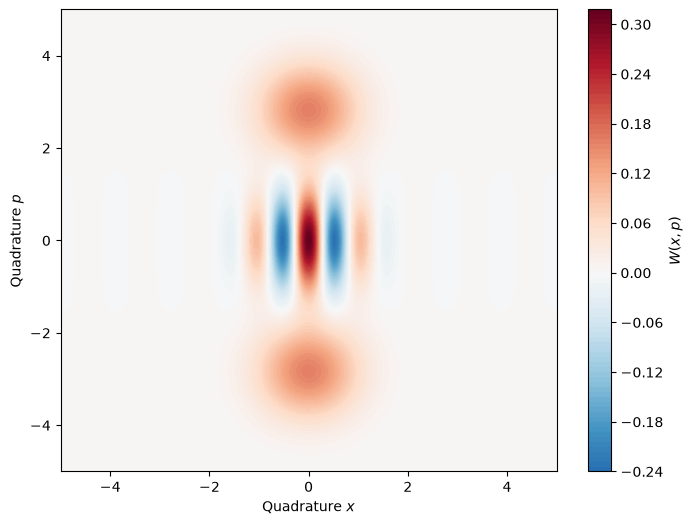

In [20]:
plot_Wigner(state)

In [21]:
# Define sampling parameters
N_angles = 8
N_samples_theta = 1000
x_range = (-5,5)
x_points = 200
x_array = np.linspace(x_range[0],x_range[1],x_points)
# Sample the selected state
thetas, samles = sample_homodyne(state=state,n_angles=N_angles,n_samples_theta=N_samples_theta,
                         bin_data=False,x_vec=x_array)

In [22]:
# Set MLE parameters
N_bins = 40

# Initialize MLE estimator
MLE_estimator = MLE(data=samles, N_bins=N_bins, N_cutoff=N_cutoff)

In [23]:
initial_rho = np.zeros((N_cutoff,N_cutoff))
initial_rho[0,0] = 1.0

R_1 = MLE_estimator.R(initial_rho)

  0%|          | 0/100 [00:00<?, ?it/s]

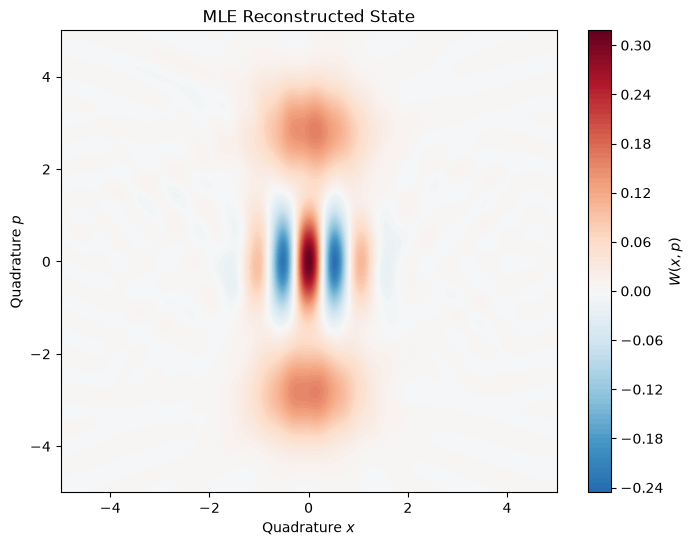

In [25]:
initial_rho = np.zeros((N_cutoff,N_cutoff))
initial_rho[0,0] = 1.0

rho_current = initial_rho
rhos = [rho_current]
for i in tqdm(range(100)):
    rho_current = MLE_estimator.one_iteration(rho_current)
    rhos.append(rho_current)
plot_Wigner(q.Qobj(rhos[-1]), xvec=x_array, title='MLE Reconstructed State')

array([-2.50135869e-01+7.88133467e-14j,  2.54628497e-01+9.25805004e-14j,
        8.35676740e-01-2.46057348e-13j,  7.97963803e-02-4.25307444e-14j,
       -3.20705978e-01+1.28070323e-13j,  1.01764414e-01-5.16527816e-14j,
        1.72002723e-01+1.07558089e-14j,  2.55066251e-03+1.13528858e-14j,
       -2.28095762e-02+1.37448784e-14j,  1.58063183e-02+2.66662874e-14j,
        1.23343322e-02+2.18396904e-15j,  1.68334384e-03-2.61489375e-15j,
        2.38855547e-03-9.58866364e-15j,  4.36090533e-03-2.02897474e-14j,
        1.72886488e-03-5.58637050e-15j,  1.82569819e-03+1.55738041e-14j,
        5.24692870e-04+1.45647663e-15j,  1.08141760e-03-5.02675098e-15j,
        2.23854523e-03+1.61683371e-15j,  9.56272730e-04+6.90588817e-15j,
        2.80255790e-04-5.14423868e-16j,  1.37886613e-03-7.98711626e-15j,
        6.05921777e-05-3.06812648e-17j,  1.34048722e-03+3.67875764e-15j,
        1.37753567e-03-2.78744211e-15j,  4.57236073e-04-3.90769122e-15j,
        7.62935816e-04+1.16127797e-15j,  3.44026809